# SEIS 766: Vision AI (SP26)
## Final Project: Latent Space Traversal
Dante Razo, razo3843@stthomas.edu

In [1]:
# set seed for reproducibility
seed: int = 42

## Configuring Environment for GPU Acceleration

In [2]:
from torch import device as torch_device
from torch import cuda

# select device and verify CUDA visibility
device: torch_device = torch_device(device="cuda" if cuda.is_available() else "cpu")
if device.type != "cuda":
    raise RuntimeError("CUDA not detected!")

# log hardware info
print(
    f"Using {str(object=device).upper()} on {cuda.get_device_name(device=cuda.current_device())}"
)

Using CUDA on NVIDIA GeForce RTX 5090


In [3]:
from os import environ

# configure keras
environ["KERAS_BACKEND"] = "torch"
environ["KERAS_TORCH_DEVICE"] = "cuda"

# reduce verbosity
enable_cuda_debug_blocking: bool = False
if enable_cuda_debug_blocking:
    environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
# check driver and GPU status
!uname -a && echo
!nvidia-smi

Linux ovedur 6.6.87.2-microsoft-standard-WSL2 #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux

Sat Apr 25 19:30:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.04              Driver Version: 596.21         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:0A:00.0  On |                  N/A |
| 30%   48C    P0             81W /  460W |    2651MiB /  32607MiB |      4%      Default |
|         

In [ ]:
from keras import backend

# configure keras for torch support
backend.set_image_data_format(data_format="channels_last")
backend.set_floatx(value="float32")
backend.clear_session()

In [ ]:
from keras.mixed_precision import Policy, set_global_policy

# set global precision policy for torch
policy: Policy = Policy(name="float32")
set_global_policy(policy=policy)

# verify global data types / policies
print(f"Compute Data Type: {policy.compute_dtype}")
print(f"Variable Data Type: {policy.variable_dtype}")

Compute Data Type: float32
Variable Data Type: float32


In [ ]:
from keras import config as keras_config

# configure keras
print(f"Keras Backend: {str(object=keras_config.backend()).capitalize()}")

Keras Backend: Torch


## Loading Convolutional Neural Networks

In [ ]:
from keras.models import Sequential, load_model

# load model into memory
cnn1: Sequential = load_model(
    filepath="CNN/melanoma_cnn_arch1_35epochs.keras", compile=False
)  # type: ignore

# adjust metadata
cnn1.name = "cnn1-shallow"
cnn1.get_layer(name="dense").name = "embedding"
cnn1.get_layer(name="dense_1").name = "output"

# preview architecture
cnn1.summary()

Model: "cnn1-shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.models import Sequential, load_model

# load model into memory
cnn2: Sequential = load_model(
    filepath="CNN/melanoma_cnn_arch2_35epochs.keras", compile=False
)  # type: ignore

# adjust metadata
cnn2.name = "cnn2-deep"
cnn2.get_layer(name="dense_2").name = "embedding"
cnn2.get_layer(name="dense_3").name = "output"

# preview architecture
cnn2.summary()

Model: "cnn2-deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## Loading Data

In [ ]:
from pandas import DataFrame, read_csv

# load ground truth metadata + classes
metadata_df: DataFrame = read_csv(
    filepath_or_buffer="../data/dante/train-ground-truth/ISIC_2020_Training_GroundTruth_v2.csv",
    usecols=["image_name", "target"],
)

# preview df
metadata_df

,image_name,target
0,ISIC_2637011,0
1,ISIC_0015719,0
2,ISIC_0052212,0
3,ISIC_0068279,0
4,ISIC_0074268,0
...,...,...
33121,ISIC_9999134,0
33122,ISIC_9999320,0
33123,ISIC_9999515,0
33124,ISIC_9999666,0


In [ ]:
from pathlib import Path


# define data directory
image_root: Path = Path("../data/dante/train/jpg")


# derive new columns
metadata_df["path"] = [  # type: ignore
    image_root / f"{image_name}.jpg" for image_name in metadata_df["image_name"]
]

# preview metadata_df
metadata_df

,image_name,target,path
0,ISIC_2637011,0,../data/dante/train/jpg/ISIC_2637011.jpg
1,ISIC_0015719,0,../data/dante/train/jpg/ISIC_0015719.jpg
2,ISIC_0052212,0,../data/dante/train/jpg/ISIC_0052212.jpg
3,ISIC_0068279,0,../data/dante/train/jpg/ISIC_0068279.jpg
4,ISIC_0074268,0,../data/dante/train/jpg/ISIC_0074268.jpg
...,...,...,...
33121,ISIC_9999134,0,../data/dante/train/jpg/ISIC_9999134.jpg
33122,ISIC_9999320,0,../data/dante/train/jpg/ISIC_9999320.jpg
33123,ISIC_9999515,0,../data/dante/train/jpg/ISIC_9999515.jpg
33124,ISIC_9999666,0,../data/dante/train/jpg/ISIC_9999666.jpg


In [ ]:
# display class distribution
metadata_df["target"].value_counts()

target
0    32542
1      584
Name: count, dtype: int64

In [ ]:
# filter to only images that exist on disk
filtered_df: DataFrame = metadata_df.loc[
    metadata_df["path"].map(func=Path.is_file)
].copy()

# print sample size reduction, if applicable
reduced_pct: float = (1 - len(filtered_df) / len(metadata_df)) * 100
if reduced_pct > 0:
    print(
        f"Sample size reduced by {reduced_pct:.2f}% "
        f"({len(metadata_df)} -> {len(filtered_df)}) after filtering!"
    )
else:
    print(f"No sample size reduction after filtering! Still {len(filtered_df)}.")

# preview filtered data
filtered_df

No sample size reduction after filtering! Still 33126.


,image_name,target,path
0,ISIC_2637011,0,../data/dante/train/jpg/ISIC_2637011.jpg
1,ISIC_0015719,0,../data/dante/train/jpg/ISIC_0015719.jpg
2,ISIC_0052212,0,../data/dante/train/jpg/ISIC_0052212.jpg
3,ISIC_0068279,0,../data/dante/train/jpg/ISIC_0068279.jpg
4,ISIC_0074268,0,../data/dante/train/jpg/ISIC_0074268.jpg
...,...,...,...
33121,ISIC_9999134,0,../data/dante/train/jpg/ISIC_9999134.jpg
33122,ISIC_9999320,0,../data/dante/train/jpg/ISIC_9999320.jpg
33123,ISIC_9999515,0,../data/dante/train/jpg/ISIC_9999515.jpg
33124,ISIC_9999666,0,../data/dante/train/jpg/ISIC_9999666.jpg


## Preprocessing Data

In [ ]:
from numpy import stack, ndarray, asarray, empty
from PIL import Image
from tqdm.auto import tqdm

# derive image dimensions from model input shape
assert cnn1.input_shape == cnn2.input_shape
img_height: int = cnn1.input_shape[1]
img_width: int = cnn1.input_shape[2]


def load_image_batch(paths: list[str]) -> ndarray:
    """Load and preprocess a batch of images."""
    image_batch: ndarray = empty(
        (len(paths), img_height, img_width, 3), dtype=policy.compute_dtype
    )

    # load and process each image (with progress bar)
    for i, path in enumerate(
        iterable=tqdm(paths, desc="Loading & Processing Images", unit="img")
    ):
        with Image.open(fp=path) as img:
            # load image and process image
            img: Image.Image = img.convert("RGB").resize(
                size=(img_width, img_height),
                resample=Image.Resampling.BILINEAR,
            )

            # normalize image and insert into batch
            image_batch[i] = asarray(a=img, dtype=policy.compute_dtype) / 255.0

    # return batch
    return image_batch

## Helper Functions for Data

In [ ]:
def filter_by_class(working_df: DataFrame, target: int) -> DataFrame:
    """Helper function to filter a DataFrame by the given class."""

    return working_df[working_df["target"] == target]

In [ ]:
from torch import Tensor


def build_latent_df(
    encoder,
    images_batch: Tensor,
    input_df: DataFrame,
    predict_batch_size: int = 512,
) -> DataFrame:
    """Build a DataFrame of latent vectors with metadata for a given encoder and input batch."""

    # assemble metadata
    names: list[str] = input_df["image_name"].tolist()
    paths: list[str] = input_df["path"].tolist()

    # assemble classes
    targets: ndarray = input_df["target"].to_numpy()

    # generate latent vectors for batch
    z_batch: ndarray = encoder.predict(
        x=images_batch,
        verbose=0,
        batch_size=min(predict_batch_size, len(input_df)),
    )

    # convert ndarray to DF
    latent_df = DataFrame(data=z_batch, index=names)

    # adjust metadata
    latent_df.index.name = "image_name"
    latent_df.columns = [f"z{i:03d}" for i in range(latent_df.shape[1])]
    latent_df.insert(loc=0, column="target", value=targets)
    latent_df.insert(loc=1, column="path", value=paths)

    return latent_df


## Defining Convolutional Neural Network Encoders

In [ ]:
from keras import Model

# instantiate encoder for first CNN
cnn1_encoder = Model(
    inputs=cnn1.inputs,
    outputs=cnn1.get_layer(name="embedding").output,
    name="cnn1_encoder",
)

# set trainable flag
cnn1_encoder.trainable = False

# preview architecture
cnn1_encoder.summary()

Model: "cnn1_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,712 (108.25 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 27,712 (108.25 KB)

In [ ]:
# instantiate encoder for second CNN
cnn2_encoder = Model(
    inputs=cnn2.inputs,
    outputs=cnn2.get_layer(name="embedding").output,
    name="cnn2_encoder",
)

# set trainable flag
cnn2_encoder.trainable = False

# preview architecture
cnn2_encoder.summary()

Model: "cnn2_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,760 (428.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 109,760 (428.75 KB)

## Representing Images in Latent Space

In [ ]:
# define sample size (smaller -> faster loading and processing)
sample_size: int = 256

# select N random samples
sampled_df: DataFrame = filtered_df.sample(
    n=sample_size, random_state=seed
).reset_index(drop=False)

# preview sampled DF shape
sampled_df.shape

(256, 4)

In [ ]:
# load common data into memory
paths: list[str] = sampled_df["path"].tolist()
batch_paths: ndarray = load_image_batch(paths=paths)


Loading & Processing Images:   0%|          | 0/256 [00:00<?, ?img/s]

In [ ]:
from torch import Tensor, from_numpy

# move data to GPU
images_tensor: Tensor = from_numpy(batch_paths).to(device=device)

In [ ]:
# build latent DataFrame for first CNN
cnn1_latent_df: DataFrame = build_latent_df(
    encoder=cnn1_encoder, images_batch=images_tensor, input_df=sampled_df
)

# preview latent df
cnn1_latent_df

,target,path,z000,z001,z002,z003,z004,z005,z006,z007,...,z118,z119,z120,z121,z122,z123,z124,z125,z126,z127
image_name,,,,,,,,,,,,,,,,,,,,,
ISIC_2566319,0,../data/dante/train/jpg/ISIC_2566319.jpg,0.120130,0.0,0.362531,0.0,0.000000,0.095270,0.0,0.0,...,0.0,0.0,0.647631,0.0,0.0,0.000000,0.0,0.0,0.0,0.645147
ISIC_6617618,0,../data/dante/train/jpg/ISIC_6617618.jpg,0.090003,0.0,0.337847,0.0,0.000000,0.112936,0.0,0.0,...,0.0,0.0,0.660079,0.0,0.0,0.000000,0.0,0.0,0.0,0.676828
ISIC_1018102,0,../data/dante/train/jpg/ISIC_1018102.jpg,0.093127,0.0,0.292028,0.0,0.000000,0.074963,0.0,0.0,...,0.0,0.0,0.571357,0.0,0.0,0.000000,0.0,0.0,0.0,0.569920
ISIC_2334999,0,../data/dante/train/jpg/ISIC_2334999.jpg,0.099256,0.0,0.255447,0.0,0.000000,0.038340,0.0,0.0,...,0.0,0.0,0.500265,0.0,0.0,0.000000,0.0,0.0,0.0,0.484962
ISIC_1151651,0,../data/dante/train/jpg/ISIC_1151651.jpg,0.126740,0.0,0.311130,0.0,0.000000,0.044941,0.0,0.0,...,0.0,0.0,0.551040,0.0,0.0,0.000000,0.0,0.0,0.0,0.537381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ISIC_1823608,0,../data/dante/train/jpg/ISIC_1823608.jpg,0.099972,0.0,0.357947,0.0,0.000000,0.124344,0.0,0.0,...,0.0,0.0,0.683982,0.0,0.0,0.000000,0.0,0.0,0.0,0.688994
ISIC_3969411,1,../data/dante/train/jpg/ISIC_3969411.jpg,0.170356,0.0,0.439208,0.0,0.003171,0.077594,0.0,0.0,...,0.0,0.0,0.680169,0.0,0.0,0.010557,0.0,0.0,0.0,0.668387
ISIC_6857991,0,../data/dante/train/jpg/ISIC_6857991.jpg,0.093744,0.0,0.270716,0.0,0.000000,0.058059,0.0,0.0,...,0.0,0.0,0.531733,0.0,0.0,0.000000,0.0,0.0,0.0,0.522309


In [ ]:
# build latent DataFrame for second CNN
cnn2_latent_df: DataFrame = build_latent_df(
    encoder=cnn2_encoder, images_batch=images_tensor, input_df=sampled_df
)

# preview latent df
cnn2_latent_df

,target,path,z000,z001,z002,z003,z004,z005,z006,z007,...,z118,z119,z120,z121,z122,z123,z124,z125,z126,z127
image_name,,,,,,,,,,,,,,,,,,,,,
ISIC_2566319,0,../data/dante/train/jpg/ISIC_2566319.jpg,0.561058,0.642441,0.262356,0.163583,0.186500,0.006837,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_6617618,0,../data/dante/train/jpg/ISIC_6617618.jpg,0.000000,0.172293,0.172561,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.026178,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_1018102,0,../data/dante/train/jpg/ISIC_1018102.jpg,0.000000,0.040253,0.000000,0.000000,0.062173,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_2334999,0,../data/dante/train/jpg/ISIC_2334999.jpg,0.000000,0.033546,0.000000,0.000000,0.083361,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_1151651,0,../data/dante/train/jpg/ISIC_1151651.jpg,0.000000,0.085501,0.000000,0.000000,0.088304,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ISIC_1823608,0,../data/dante/train/jpg/ISIC_1823608.jpg,0.231978,0.410027,0.260436,0.000000,0.048601,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_3969411,1,../data/dante/train/jpg/ISIC_3969411.jpg,0.194097,0.332809,0.038029,0.017577,0.098696,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_6857991,0,../data/dante/train/jpg/ISIC_6857991.jpg,0.000000,0.053534,0.000000,0.000000,0.068694,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


## Defining Convolutional Neural Network Decoders

In [ ]:
from keras import Input, Model
from keras.layers import Dense, Reshape, Conv2D, UpSampling2D


def build_decoder(
    latent_dim=128, start_shape=(14, 14, 128), out_channels=3, name="decoder"
) -> Model:
    """Manually define decoder"""
    h, w, c = start_shape

    # input layer
    latent_inputs = Input(shape=(latent_dim,), name="latent_input")
    input: Dense = Dense(units=h * w * c, activation="relu")(latent_inputs)
    reshaped: Reshape = Reshape(target_shape=(h, w, c))(input)

    # hidden layers
    dense1: UpSampling2D = UpSampling2D(size=2)(reshaped)
    dense2: Conv2D = Conv2D(
        filters=128, kernel_size=3, padding="same", activation="relu"
    )(dense1)

    dense3: UpSampling2D = UpSampling2D(size=2)(dense2)
    dense4: Conv2D = Conv2D(
        filters=64, kernel_size=3, padding="same", activation="relu"
    )(dense3)

    dense3: UpSampling2D = UpSampling2D(size=2)(dense4)
    dense4: Conv2D = Conv2D(
        filters=32, kernel_size=3, padding="same", activation="relu"
    )(dense3)

    dense5: UpSampling2D = UpSampling2D(size=2)(dense4)
    dense6: Conv2D = Conv2D(
        filters=16, kernel_size=3, padding="same", activation="relu"
    )(dense5)

    # output layer
    outputs: Conv2D = Conv2D(
        filters=out_channels,
        kernel_size=3,
        padding="same",
        activation="sigmoid",
        name="reconstruction",
    )(dense6)

    return Model(latent_inputs, outputs, name=name)


def build_autoencoder(encoder, decoder, name="autoencoder") -> Model:
    """Given encoder and decoder, build an autoencoder"""
    return Model(encoder.input, decoder(encoder.output), name=name)

In [ ]:
# build decoders
cnn1_decoder: Model = build_decoder(latent_dim=128, name="cnn1_decoder")
cnn2_decoder: Model = build_decoder(latent_dim=128, name="cnn2_decoder")


In [ ]:
from numpy import ceil

# define common autoencoder hyperparameters
epochs: int = 200
batch_size: int = int(ceil(sample_size / 8))  # scales with sample size

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from livelossplot import PlotLossesKeras
from livelossplot.outputs import MatplotlibPlot
from typing import Any

# define callbacks
fit_callbacks: list[Any] = [
    PlotLossesKeras(outputs=[MatplotlibPlot(figsize=(20, 6))]),
    EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

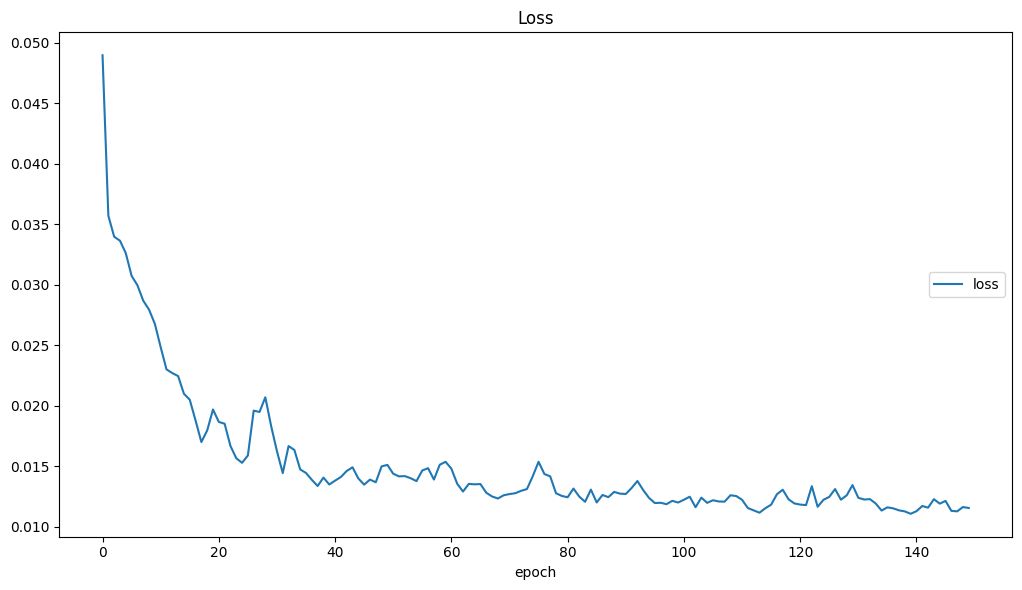

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0116 - learning_rate: 0.0010


In [ ]:
from keras.callbacks import History

# build autoencoder for CNN1
cnn1_ae: Model = build_autoencoder(
    encoder=cnn1_encoder, decoder=cnn1_decoder, name="cnn1_ae"
)

# compile autoencoder
cnn1_ae.compile(optimizer="adam", loss="mse")

# fit autoencoder
fit_history: History = cnn1_ae.fit(
    x=images_tensor,
    y=images_tensor,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=fit_callbacks,
    shuffle=True,
)

In [ ]:
# build autoencoder for CNN2
cnn2_ae: Model = build_autoencoder(
    encoder=cnn2_encoder, decoder=cnn2_decoder, name="cnn2_ae"
)

# compile autoencoder
cnn2_ae.compile(optimizer="adam", loss="mse")

# fit autoencoder
cnn2_ae.fit(
    x=images_tensor,
    y=images_tensor,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
)


Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0605
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0404
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0304
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0238
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0211
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0194
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0177
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0162
Epoch 9/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0150
Epoch 10/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0145
Epoch 11/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0135
Epoch 12/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0141
Epoch 13/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0132
Epoch 14/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0133
Epoch 15/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0130
Epoch 16/150
8/8 ━━

## Helper Functions for Latent Space Traversal

In [ ]:
from pandas import DataFrame
from numpy import linspace


def interpolate_latents(z_start, z_end, steps=10):
    alphas: ndarray = linspace(start=0.0, stop=1.0, num=steps, dtype=float)[:, None]

    return (1.0 - alphas) * z_start[None, :] + alphas * z_end[None, :]


# TODO: better typing, returns, etc.
def walk_latent_pairs(latent_df, decoder, pair_indices, steps=10):
    latent_cols = [c for c in latent_df.columns if c.startswith("z")]
    walks = []
    meta_rows = []

    for pair_id, (i, j) in enumerate(pair_indices):
        row_a = latent_df.iloc[i]
        row_b = latent_df.iloc[j]

        z_a = row_a[latent_cols].to_numpy(dtype=policy.compute_dtype)
        z_b = row_b[latent_cols].to_numpy(dtype=policy.compute_dtype)
        z_path = interpolate_latents(z_start=z_a, z_end=z_b, steps=steps)

        decoded = decoder.predict(
            z_path,
            verbose=0,
            batch_size=min(batch_size, len(z_path)),
        )

        walks.append(decoded)

        for step, alpha in enumerate(
            iterable=linspace(
                start=0.0, stop=1.0, num=steps, dtype=policy.compute_dtype
            )
        ):
            meta_rows.append(
                {
                    "pair_id": pair_id,
                    "step": step,
                    "alpha": float(alpha),
                    "start_name": latent_df.index[i],
                    "end_name": latent_df.index[j],
                }
            )

    return walks, DataFrame(data=meta_rows)

In [ ]:
# number of pairs to walk between
n: int = 3

# TODO: random order?
# TODO: ensure same class?
# assemble pairs
pair_indices: list[tuple[int, int]] = [(i, i + 1) for i in range(0, n * 2, 2)]

In [ ]:
import matplotlib.pyplot as plt

from numpy import clip
from pandas import DataFrame
from keras import Model


def plot_walk(latent_df: DataFrame, decoder: Model, steps: int = 10) -> None:
    walks, walk_meta = walk_latent_pairs(
        latent_df=latent_df,
        decoder=decoder,
        pair_indices=pair_indices,
        steps=steps,
    )

    for i, imgs in enumerate(walks):
        meta: DataFrame = walk_meta[walk_meta["pair_id"] == i].reset_index(drop=True)

        start_name: str = str(meta.loc[0, "start_name"])
        end_name: str = str(meta.loc[0, "end_name"])
        alphas = meta["alpha"].to_numpy()
        step_nums = meta["step"].to_numpy()

        fig, axes = plt.subplots(
            nrows=1, ncols=len(imgs), figsize=(2.4 * len(imgs), 3.2)
        )

        if len(imgs) == 1:
            axes = [axes]

        middle_label: str = f"{start_name} → {end_name}"

        for j, (ax, img, alpha, step_num) in enumerate(
            zip(axes, imgs, alphas, step_nums)
        ):
            ax.imshow(clip(img, 0, 1))
            ax.set_title(f"Step {step_num}\nα={alpha:.3f}", fontsize=10)

            if j == 0:
                label: str = f"{start_name} (Start)"
            elif j == len(imgs) - 1:
                label: str = f"{end_name} (End)"
            else:
                label: str = middle_label

            ax.set_xlabel(label, fontsize=9, labelpad=8)
            ax.set_xticks([])
            ax.set_yticks([])

        plt.tight_layout()
        plt.show()

## Walking Between Images in Latent Space

In [ ]:
# define common walk hyperparameters
steps: int = 7

### CNN Architecture #1

In [ ]:
plot_walk(latent_df=cnn1_latent_df, decoder=cnn1_decoder, steps=steps)

### CNN Architecture #2

In [ ]:
plot_walk(latent_df=cnn2_latent_df, decoder=cnn2_decoder, steps=steps)